# Full-Dataset Training + Comparison

The companion notebook to `model_training_finetuning.ipynb`, which
demonstrates both techniques (AutoGluon tabular baseline vs. attention-
pooling deep model) on a bounded `SAMPLE_FRACTION` subset for fast
iteration. On that bounded run, the deep model (Section B, test accuracy
0.491) trailed the tabular baseline (Section A, test accuracy 0.584) —
plausibly because it's more data-hungry (learning an attention head from
scratch over 768-d embeddings) than the tabular baseline (a low-dimensional,
pre-aggregated feature set).

This notebook answers that directly: train both techniques on the **full**
labeled dataset (no sampling) and compare real performance. See
`docs/model_architecture.md` and `model_training_finetuning.ipynb` for the
architecture rationale and preprocessing validation — not repeated here.

The turn-feature cache (`data/generated/turn_features/`) already covers all
3,056 transcripts, so no re-run of `precompute_turn_features.py` is needed.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from modeling.features import aggregate_tabular_features
from modeling.dataset import TurnFeatureDataset, collate_fn
from modeling.model import AttentionPoolingClassifier
from modeling.training import (
    time_based_split,
    train_model,
    predict,
    plot_training_curves,
    plot_confusion_matrix,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

TRANSCRIPTS_PATH = PROJECT_ROOT / "data" / "generated" / "labeled_transcripts.parquet"
TURN_FEATURES_DIR = PROJECT_ROOT / "data" / "generated" / "turn_features"

Using device: cuda


## 1. Load data (full dataset, no sampling)

In [2]:
transcripts = pd.read_parquet(TRANSCRIPTS_PATH)
transcripts["call_date"] = pd.to_datetime(transcripts["call_date"])

turn_metadata = pd.read_parquet(TURN_FEATURES_DIR / "turn_metadata.parquet")
turn_embeddings = np.load(TURN_FEATURES_DIR / "turn_embeddings.npy")

print(f"transcripts      : {transcripts.shape}")
print(f"turn_metadata    : {turn_metadata.shape}")
print(f"turn_embeddings  : {turn_embeddings.shape}")
assert len(turn_metadata) == len(turn_embeddings), "turn_metadata and turn_embeddings must be row-aligned"

transcripts      : (3056, 17)
turn_metadata    : (227787, 10)
turn_embeddings  : (227787, 768)


## 2. Target, full-dataset split, and split visualization

Same binary target as notebook 1 (`excess_return_label > 0`), same
chronological `time_based_split` — but over every row, not a sampled
subset.

In [3]:
labels_df = pd.DataFrame(
    {
        "label": (transcripts["excess_return_label"] > 0).astype(int),
        "call_date": transcripts["call_date"],
    },
    index=transcripts.index,
)
labels_df.index.name = "row_id"

print(f"Full dataset: {len(labels_df)} rows")
print("Class balance:")
print(labels_df["label"].value_counts(normalize=True))

Full dataset: 3056 rows
Class balance:
label
1    0.518652
0    0.481348
Name: proportion, dtype: float64


In [4]:
train_labels, val_labels, test_labels = time_based_split(labels_df, train_frac=0.7, val_frac=0.15)

for name, split_df in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    print(
        f"{name:5s}: n={len(split_df):4d}  "
        f"dates=[{split_df['call_date'].min().date()} .. {split_df['call_date'].max().date()}]  "
        f"positive_rate={split_df['label'].mean():.3f}"
    )

assert len(train_labels) + len(val_labels) + len(test_labels) == len(labels_df)

train: n=2139  dates=[2017-11-22 .. 2022-01-20]  positive_rate=0.514
val  : n= 458  dates=[2022-01-21 .. 2022-07-19]  positive_rate=0.557
test : n= 459  dates=[2022-07-19 .. 2023-02-15]  positive_rate=0.501


In [5]:
split_assignment = pd.concat(
    [
        train_labels.assign(split="train"),
        val_labels.assign(split="val"),
        test_labels.assign(split="test"),
    ]
).join(transcripts[["ticker"]])
split_assignment = split_assignment[["ticker", "call_date", "label", "split"]].sort_values("call_date")

split_summary = split_assignment.groupby("split", sort=False).agg(
    n=("label", "size"),
    date_min=("call_date", "min"),
    date_max=("call_date", "max"),
    positive_rate=("label", "mean"),
).loc[["train", "val", "test"]]
split_summary

,n,date_min,date_max,positive_rate
split,,,,
train,2139,2017-11-22,2022-01-20,0.514259
val,458,2022-01-21,2022-07-19,0.556769
test,459,2022-07-19,2023-02-15,0.501089


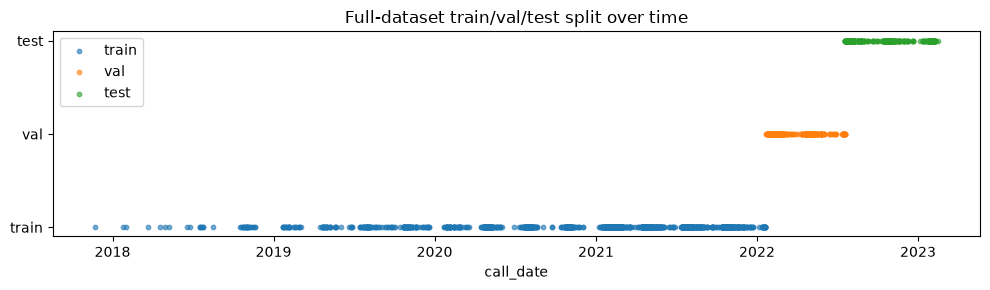

In [6]:
SPLIT_ORDER = ["train", "val", "test"]
SPLIT_Y = {split: i for i, split in enumerate(SPLIT_ORDER)}
SPLIT_COLOR = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green"}

fig, ax = plt.subplots(figsize=(10, 3))
for split in SPLIT_ORDER:
    subset = split_assignment[split_assignment["split"] == split]
    ax.scatter(
        subset["call_date"],
        [SPLIT_Y[split]] * len(subset),
        color=SPLIT_COLOR[split],
        label=split,
        s=10,
        alpha=0.6,
    )

ax.set_yticks(list(SPLIT_Y.values()))
ax.set_yticklabels(SPLIT_ORDER)
ax.set_xlabel("call_date")
ax.set_title("Full-dataset train/val/test split over time")
ax.legend(loc="upper left")
fig.tight_layout()

## Section A — AutoGluon, full data

In [7]:
tabular_features = aggregate_tabular_features(turn_metadata).set_index("row_id")

def build_tabular_split(label_split_df):
    return tabular_features.join(label_split_df[["label"]], how="inner")

tabular_train = build_tabular_split(train_labels)
tabular_val = build_tabular_split(val_labels)
tabular_test = build_tabular_split(test_labels)

print(f"tabular_train: {tabular_train.shape}, tabular_val: {tabular_val.shape}, tabular_test: {tabular_test.shape}")

tabular_train: (2139, 51), tabular_val: (458, 51), tabular_test: (459, 51)


In [8]:
AUTOGLUON_TIME_LIMIT = 300  # seconds; wall-clock cap on AutoGluon's search (full data, more headroom than notebook 1)

from autogluon.tabular import TabularPredictor

autogluon_predictor = TabularPredictor(
    label="label",
    problem_type="binary",
    eval_metric="accuracy",
    path=str(PROJECT_ROOT / "data" / "generated" / "models" / "autogluon_tabular_full"),
    verbosity=1,
).fit(
    train_data=tabular_train,
    tuning_data=tabular_val,
    time_limit=AUTOGLUON_TIME_LIMIT,
)

autogluon_predictor.leaderboard(tabular_test)

		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.6.1`.


		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.6.1`.


		`import catboost` failed. A quick tip is to install via `pip install autogluon.tabular[catboost]==1.6.1`.


		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.6.1`. 


		`import xgboost` failed. A quick tip is to install via `pip install autogluon.tabular[xgboost]==1.6.1`.


		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.6.1`.


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,ExtraTreesGini,0.472767,0.539301,accuracy,0.090895,0.063863,0.501648,0.090895,0.063863,0.501648,1,True,3
1,NeuralNetTorch,0.466231,0.558952,accuracy,0.014380,0.011439,2.999723,0.014380,0.011439,2.999723,1,True,5
2,ExtraTreesEntr,0.464052,0.539301,accuracy,0.084023,0.053229,0.563148,0.084023,0.053229,0.563148,1,True,4
3,WeightedEnsemble_L2,0.455338,0.578603,accuracy,0.197110,0.140682,4.648744,0.001436,0.000712,0.027778,2,True,6
4,RandomForestGini,0.450980,0.515284,accuracy,0.090400,0.064668,1.119595,0.090400,0.064668,1.119595,1,True,1
5,RandomForestEntr,0.440087,0.493450,accuracy,0.075879,0.053604,1.296294,0.075879,0.053604,1.296294,1,True,2


In [9]:
train_acc = autogluon_predictor.evaluate(tabular_train)["accuracy"]
val_acc = autogluon_predictor.evaluate(tabular_val)["accuracy"]
test_acc = autogluon_predictor.evaluate(tabular_test)["accuracy"]
print(f"train accuracy: {train_acc:.3f}")
print(f"val   accuracy: {val_acc:.3f}")
print(f"test  accuracy: {test_acc:.3f}")

train accuracy: 0.997
val   accuracy: 0.579
test  accuracy: 0.455


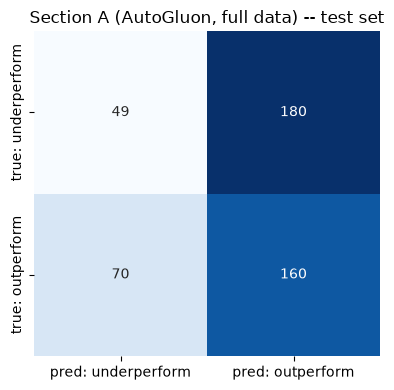

In [10]:
tabular_preds = autogluon_predictor.predict(tabular_test.drop(columns=["label"]))
fig = plot_confusion_matrix(tabular_test["label"].tolist(), tabular_preds.tolist(), title="Section A (AutoGluon, full data) -- test set")

## Section B — Deep attention-pooling model, full data

Same Optuna-search-then-final-fit structure as notebook 1's Section B, but
over the full dataset. Turn embeddings are already cached (no FinBERT
forward passes happen here), so training stays cheap even at this scale —
budget constants are raised since data volume, not compute, was the
limiting factor before.

In [11]:
EMBEDDING_DIM = turn_embeddings.shape[1]

train_dataset = TurnFeatureDataset(turn_metadata, turn_embeddings, train_labels["label"])
val_dataset = TurnFeatureDataset(turn_metadata, turn_embeddings, val_labels["label"])
test_dataset = TurnFeatureDataset(turn_metadata, turn_embeddings, test_labels["label"])

from torch.utils.data import DataLoader

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)

In [12]:
N_OPTUNA_TRIALS = 15   # search budget (full data, more headroom than notebook 1)
MAX_EPOCHS = 25         # per-trial (and final-run) training depth cap

import optuna

def objective(trial):
    model = AttentionPoolingClassifier(
        embedding_dim=EMBEDDING_DIM,
        role_dim=trial.suggest_categorical("role_dim", [8, 16, 32]),
        attention_dim=trial.suggest_categorical("attention_dim", [64, 128, 256]),
        dropout=trial.suggest_float("dropout", 0.0, 0.5),
    )
    history = train_model(
        model,
        train_loader,
        val_loader,
        max_epochs=MAX_EPOCHS,
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        device=DEVICE,
        patience=4,
    )
    return min(history.val_loss)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_OPTUNA_TRIALS)

print("Best val loss:", study.best_value)
print("Best params:", study.best_params)

/home/nflanaga/ML2026/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Best val loss: 0.6773989427037634
Best params: {'role_dim': 16, 'attention_dim': 128, 'dropout': 0.23084191444192176, 'lr': 0.0002667033773737728, 'weight_decay': 0.00020960377818710077}


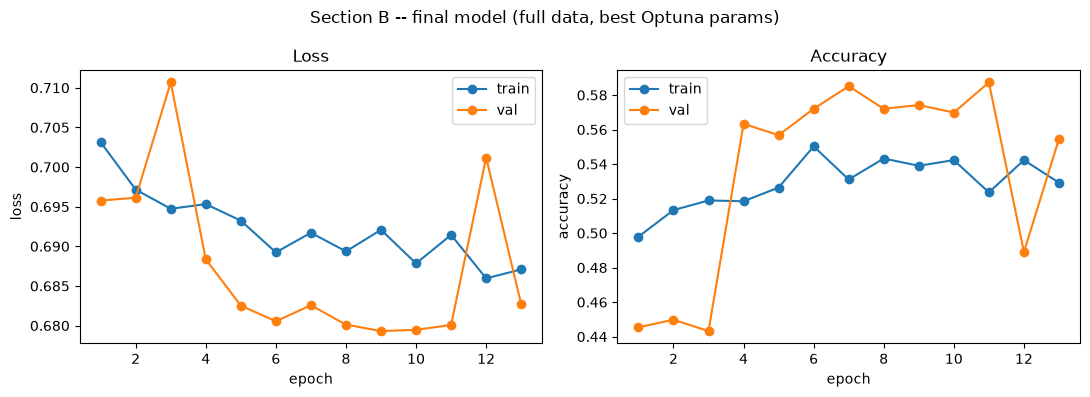

In [13]:
best_params = study.best_params
final_model = AttentionPoolingClassifier(
    embedding_dim=EMBEDDING_DIM,
    role_dim=best_params["role_dim"],
    attention_dim=best_params["attention_dim"],
    dropout=best_params["dropout"],
)
final_history = train_model(
    final_model,
    train_loader,
    val_loader,
    max_epochs=MAX_EPOCHS,
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
    device=DEVICE,
    patience=4,
)

fig = plot_training_curves(final_history, title="Section B -- final model (full data, best Optuna params)")

Section B test accuracy: 0.492


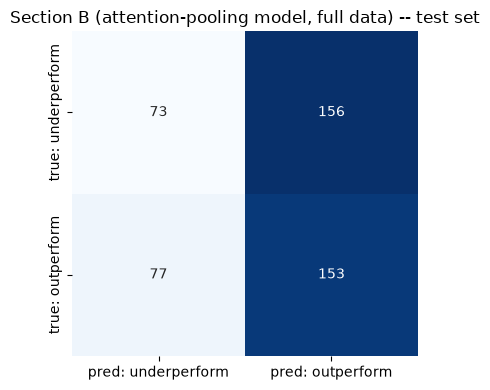

In [14]:
y_true, y_pred = predict(final_model, test_loader, device=DEVICE)
test_accuracy = sum(int(a == b) for a, b in zip(y_true, y_pred)) / len(y_true)
print(f"Section B test accuracy: {test_accuracy:.3f}")

fig = plot_confusion_matrix(y_true, y_pred, title="Section B (attention-pooling model, full data) -- test set")

## 3. Section A vs. Section B comparison (full dataset)

In [15]:
comparison = pd.DataFrame(
    [
        {"section": "A (AutoGluon tabular)", "train_acc": train_acc, "val_acc": val_acc, "test_acc": test_acc},
        {
            "section": "B (attention-pooling)",
            "train_acc": final_history.train_acc[-1],
            "val_acc": final_history.val_acc[-1],
            "test_acc": test_accuracy,
        },
    ]
)
comparison

,section,train_acc,val_acc,test_acc
0,A (AutoGluon tabular),0.996727,0.578603,0.455338
1,B (attention-pooling),0.529219,0.554585,0.492375


## 4. Interpretation: a faint (or absent) signal

Taken at face value, neither section beats a coin flip on held-out data,
and the two sections actually disagree with the bounded demo in
`model_training_finetuning.ipynb`:

- **Section A collapses from a train accuracy of 0.997 to a test accuracy
  of 0.455.** That gap *is* the finding: with 51 engineered features and
  ~2,100 training rows, tree ensembles memorized the training set. Its
  bounded-run test accuracy (0.584, on ~750 rows) was very likely a small-
  sample fluke rather than a real, generalizing edge — the full-data run is
  the more trustworthy number precisely because it's worse.
- **Section B barely moves** (0.491 on the bounded subset -> 0.492 on the
  full dataset) despite 3x the training data and a wider hyperparameter
  search. That rules out sample size as the bottleneck for the deep model —
  more data did not surface signal that wasn't already visible on the
  smaller run.

**Reading both together**: this project does not find a reliable signal
that earnings-call transcript text alone predicts market-relative excess
return over this lag window. That's a legitimate result, not a failed
pipeline — it's consistent with market efficiency, where professional
quant research on earnings-call NLP typically reports thin edges that
require much larger corpora, additional signal sources (analyst revisions,
order flow, alternative data), and more rigorous evaluation than a single
text source and ~3k labeled examples can produce.

It's also worth noting the verification methodology built into this
project is *why* this was caught cleanly: a chronological split plus an
explicit train-vs-val/test comparison surfaced Section A's overfitting
immediately. A less careful evaluation (a random split, or reporting only
the bounded-subset numbers) could easily have presented 0.584 as a real
result.

**What would be needed to pursue this further** (out of scope here, noted
for the record): a regularized/cross-validated tabular baseline instead of
a single train/val split; a precision-at-confidence analysis (does the
model have any edge on its most-confident predictions, even if overall
accuracy is near chance) rather than raw accuracy across all predictions;
and/or additional data sources beyond transcript text alone.